S
M
A
R
T

### Problem Statement

- Karakteristik rumah dengan harga diatas/dibawah rata rata dan anomali

APa yang membedakan harga rumah dibawah/diatas rata rata

In [1]:
# Import Library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [99]:
df = pd.read_csv('./Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [30]:
df.shape

(545, 13)

In [54]:
df[df.duplicated()]

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,status


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [65]:
from scipy import stats

skewness = stats.skew(df['price'])
print(f"Skewness: {skewness:.4f}")

if -0.5 < skewness < 0.5:
    print("Distribusi normal ✅")
elif -1.0 < skewness <= -0.5 or 0.5 <= skewness < 1.0:
    print("Sedikit miring ⚠️")
else:
    print("Sangat miring ❌")

Skewness: 1.2089
Sangat miring ❌


In [66]:
from scipy import stats

skewness = stats.skew(df['area'])
print(f"Skewness: {skewness:.4f}")

if -0.5 < skewness < 0.5:
    print("Distribusi normal ✅")
elif -1.0 < skewness <= -0.5 or 0.5 <= skewness < 1.0:
    print("Sedikit miring ⚠️")
else:
    print("Sangat miring ❌")

Skewness: 1.3175
Sangat miring ❌


In [100]:
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

In [101]:
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

In [75]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,NaN
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,NaN
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,NaN
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,NaN


In [ ]:
ingin diuji: luas rumah di atas rata memiliki harga rumah yang lebih mahal dibandingkan luas rumah di bawah rata rata 

hr1 = harga rumah diatas luas rata rata
hr2 = harga rumah dibawah luas rata rata

h0: hr1 <= hr2
h1: hr1 > hr2

In [117]:
mean_area = df['area'].mean()

df['area_group'] = df['area'].apply(lambda x: 'Above Avg' if x > mean_area else 'Below Avg')
above = df[df['area_group'] == 'Above Avg']['price']
below = df[df['area_group'] == 'Below Avg']['price']


from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(above, below, alternative='greater')

print("T-statistic:", t_stat)
print("P-value:", p_value)
alpha = 0.05

if p_value < alpha:
    print("Tolak H0 → Rumah dengan luas di atas rata-rata memang lebih mahal")
else:
    print("Gagal tolak H0 → Tidak cukup bukti")

T-statistic: 14.507138706268693
P-value: 7.673481497603069e-41
Tolak H0 → Rumah dengan luas di atas rata-rata memang lebih mahal


<Axes: >

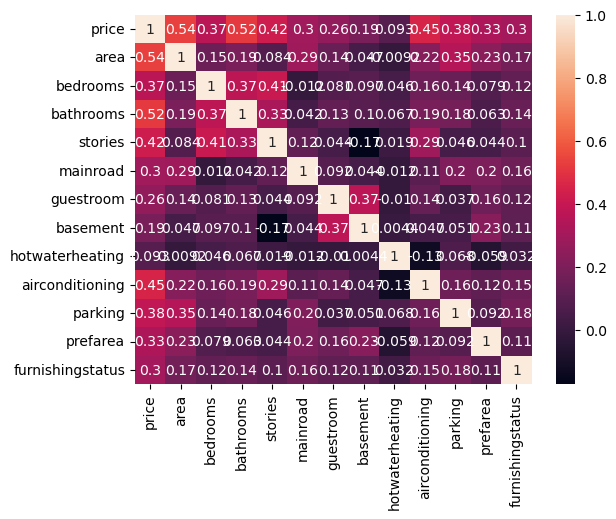

In [121]:
sns.heatmap(df.iloc[:,:-2].corr(),annot=True)

### Bakcground

### Problem Statement

### Objective

In [29]:
df.shape

(545, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [20]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


<Axes: ylabel='price'>

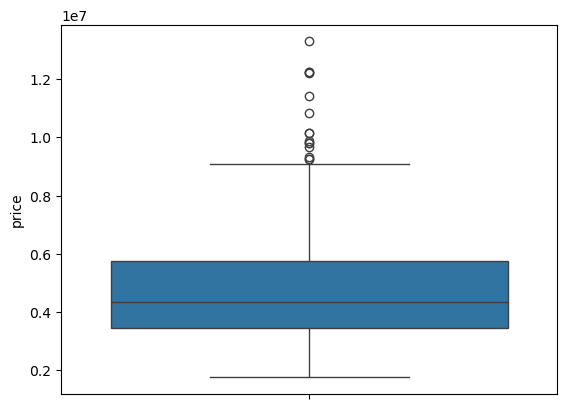

In [44]:
sns.boxplot(df['price'])

In [111]:
df['price'].min(), df['price'].max() 

(1750000, 13300000)

- dapetin mean
- dapetin outlier
- tambah kolom baru, isinyna ini data outlier, above, below

In [103]:
iqr = df['price'].quantile(0.75) - df['price'].quantile(0.25)

def get_status(price):
    if price > df['price'].quantile(0.75) + 1.5 * iqr:
        return 'outliers'
    elif price > df['price'].mean():
        return 'above_avg'
    elif price <= df['price'].mean():
        return 'below_avg'
    
    
df['status'] = df['price'].apply(get_status)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,status
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2,outliers
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2,outliers
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,outliers
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2,outliers
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2,outliers


In [80]:
above_avg = df[df['status'] == 'above_avg']
below_avg = df[df['status'] == 'below_avg']
outlier = df[df['status'] == 'outliers']

In [107]:
outlier

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,status
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,NaN,outliers
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,NaN,outliers
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1.0,outliers
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,NaN,outliers
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,NaN,outliers
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1.0,outliers
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1.0,outliers
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0.0,outliers
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,NaN,outliers
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0.0,outliers


<Axes: xlabel='status', ylabel='bedrooms'>

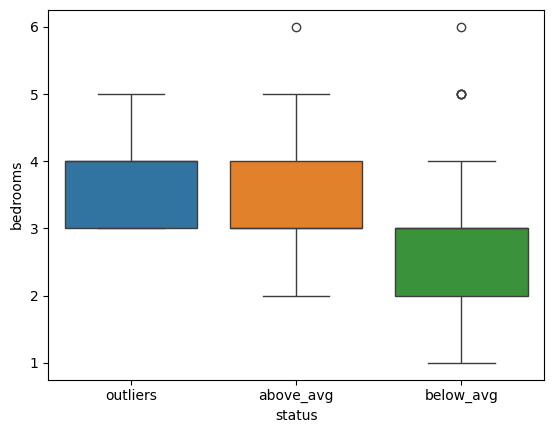

In [92]:
sns.boxplot(y=df['bedrooms'],x=df['status'], hue=df['status'])

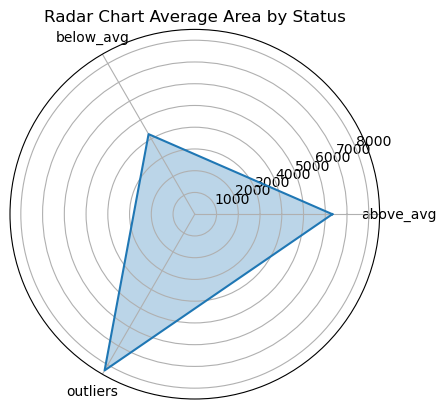

In [108]:
avg_area = df.groupby('status')['area'].mean()

labels = avg_area.index.tolist()
values = avg_area.values.tolist()

# tutup lingkaran
values += values[:1]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(subplot_kw={'polar': True})

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title('Radar Chart Average Area by Status')
plt.show()

# Insigt
Outlier: 
- rata rata memiliki area rumah yang lebih luas daripada above, dan below average
- mayoritas Berada di area yang disukai (prefarea)
- selalu terhubung ke jalan besar / raya / main road

Above Average:
- 

Below average:
- rata rata rumah paling kecil diantara kedua
- kebanyakan 

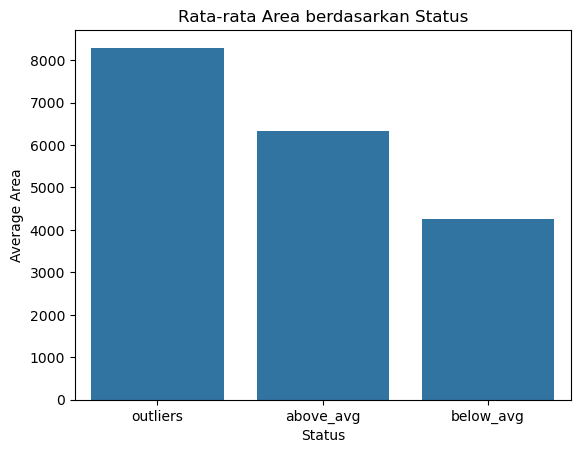

In [95]:
avg_area = df.groupby('status')['area'].mean().reset_index().sort_values('area', ascending=False)
sns.barplot(x='status', y='area', data=avg_area)

plt.title('Rata-rata Area berdasarkan Status')
plt.xlabel('Status')
plt.ylabel('Average Area')
plt.show()

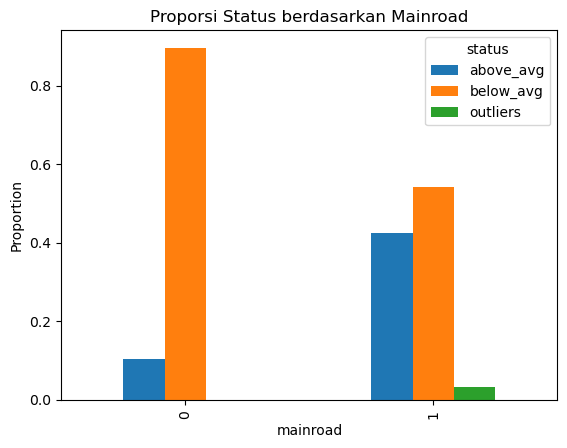

In [125]:
ct = pd.crosstab(df['mainroad'], df['status'], normalize='index')
ct.plot(kind='bar')

plt.title('Proporsi Status berdasarkan Mainroad')
plt.ylabel('Proportion')
plt.show()

In [116]:
df[['price','area']].corr()

,price,area
price,1.000000,0.535997
area,0.535997,1.000000


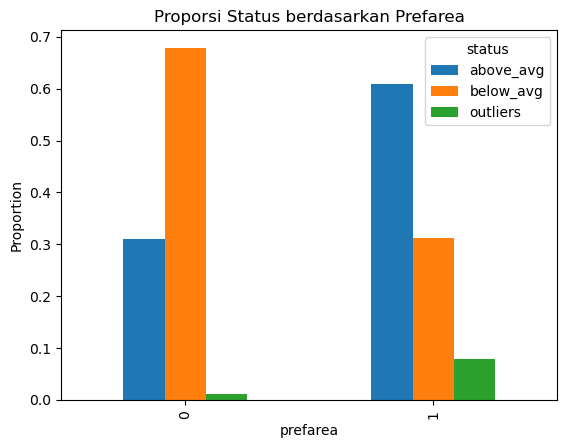

In [106]:
import pandas as pd

ct = pd.crosstab(df['prefarea'], df['status'], normalize='index')

ct.plot(kind='bar')

plt.title('Proporsi Status berdasarkan Prefarea')
plt.ylabel('Proportion')
plt.show()

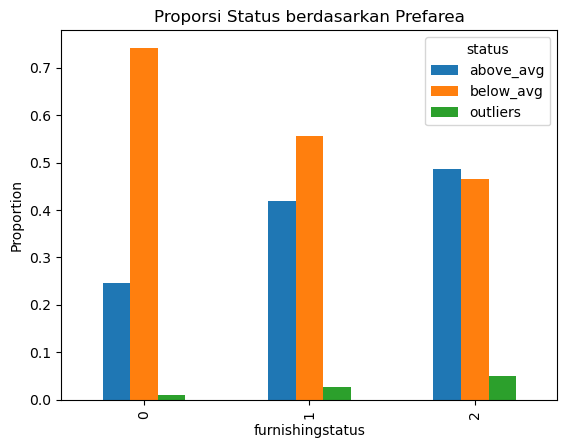

In [112]:
import pandas as pd

ct = pd.crosstab(df['furnishingstatus'], df['status'], normalize='index')

ct.plot(kind='bar')

plt.title('Proporsi Status berdasarkan Prefarea')
plt.ylabel('Proportion')
plt.show()

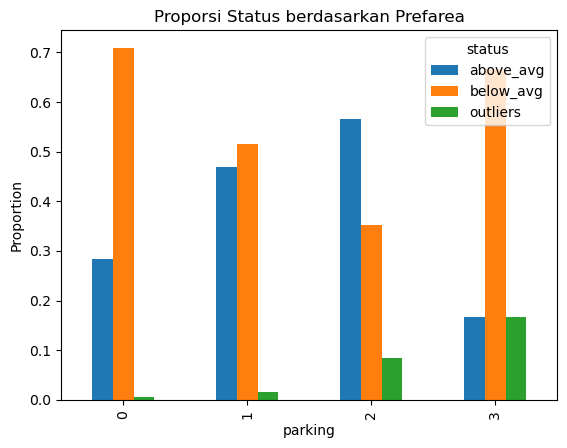

In [126]:
import pandas as pd

ct = pd.crosstab(df['parking'], df['status'], normalize='index')

ct.plot(kind='bar')

plt.title('Proporsi Status berdasarkan Prefarea')
plt.ylabel('Proportion')
plt.show()

In [ ]:
import pandas as pd

ct = pd.crosstab(df['furnishingstatus'], df['status'], normalize='index')

ct.plot(kind='bar')

plt.title('Proporsi Status berdasarkan Prefarea')
plt.ylabel('Proportion')
plt.show()

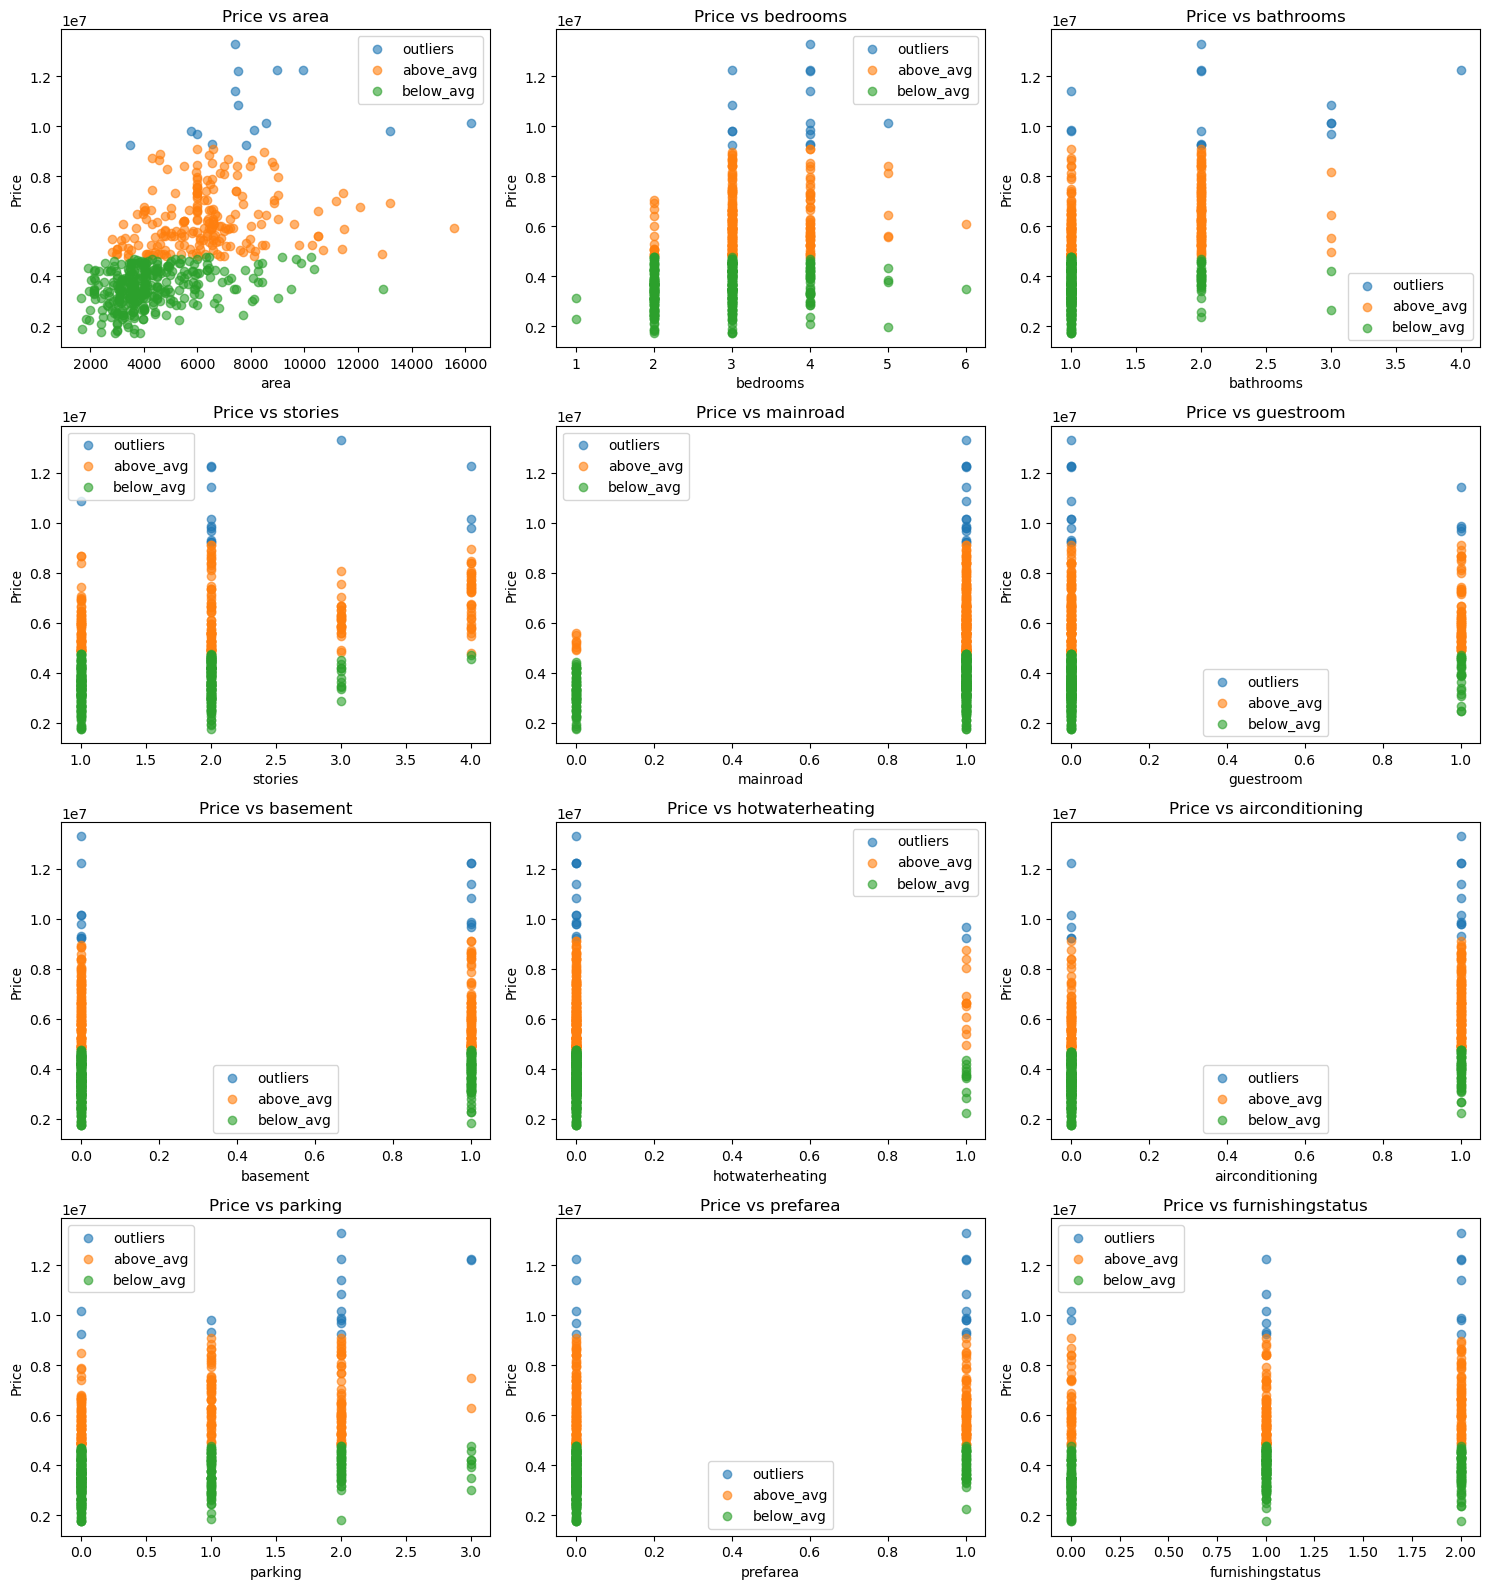

In [104]:
import math

# Ambil semua kolom numerik kecuali 'price'
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'price']

# Atur layout grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

# Ambil unique status
statuses = df['status'].unique()

for i, col in enumerate(numeric_cols):
    for status in statuses:
        subset = df[df['status'] == status]
        axes[i].scatter(
            subset[col],
            subset['price'],
            label=status,
            alpha=0.6
        )
    
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Price vs {col}')
    axes[i].legend()

# Sembunyikan subplot kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

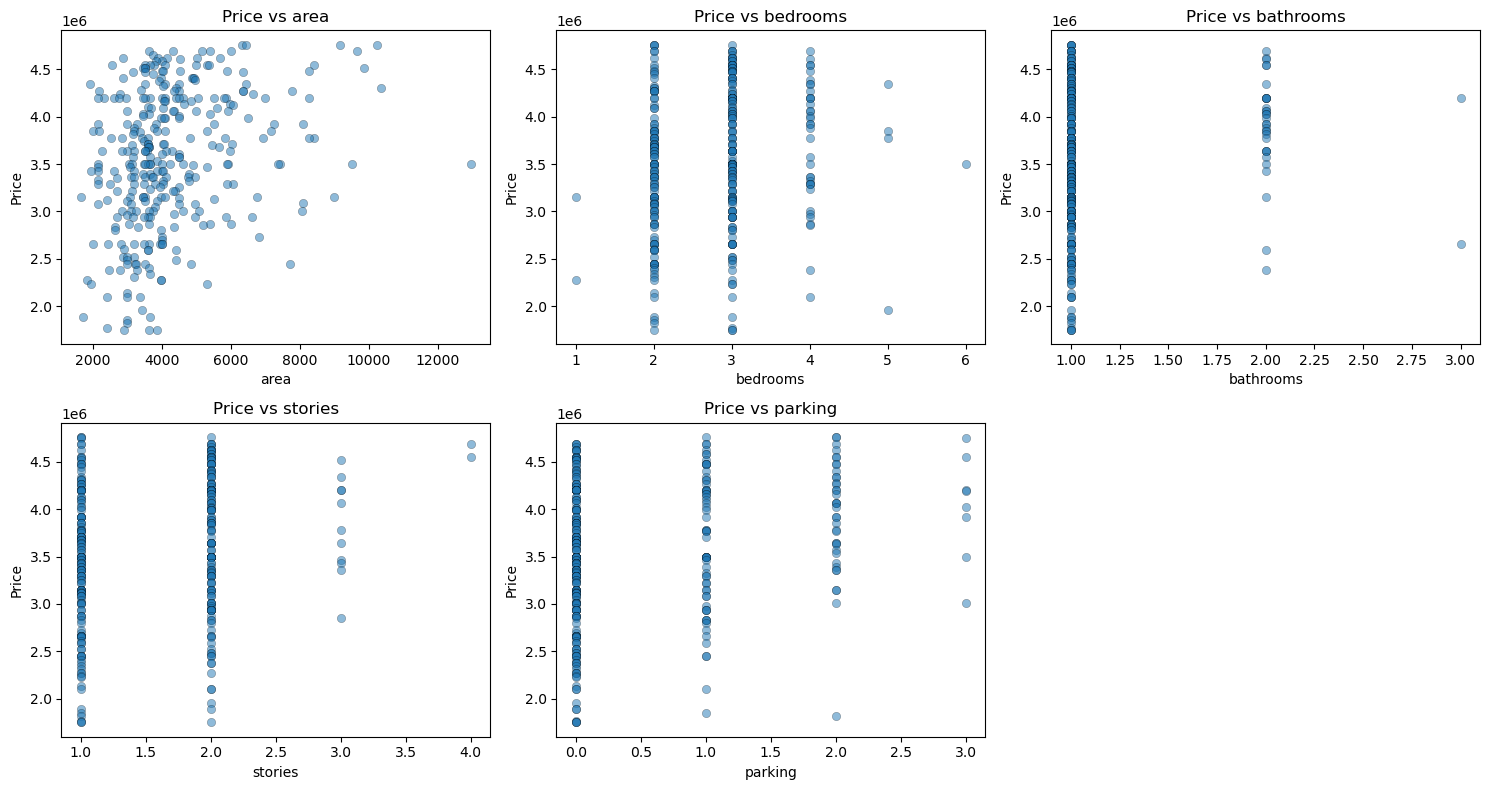

In [52]:
import math
# Ambil semua kolom numerik kecuali 'price' itu sendiri
numeric_cols = below_avg.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'price']

# Atur layout grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(below_avg[col], below_avg['price'], alpha=0.5, edgecolors='k', linewidths=0.3)
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Price vs {col}')

# Sembunyikan subplot kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Objective
- Cari variable yang mempengaruhi harga rumah

### Step
- Cek distribusi data, apakah ada anomali
- melakukan uji korelasi antar variable yang mempengaruhi price

In [28]:
print(f"Rata-rata harga rumah: {df['price'].mean()}")
print(f"Median harga rumah: {df['price'].median()}")
print(f"Standar deviasi harga rumah: {np.std(df['price'])}")
print(f"Range harga rumah: {df['price'].max() - df['price'].min()}")
print()
print(f"Rata-rata luas rumah (sq.ft): {df['area'].mean()}")
print(f"Median luas rumah (sq.ft): {df['area'].median()}")
print(f"Standar deviasi luas rumah (sq.ft): {np.std(df['area'])}")
print(f"Range luas rumah (sq.ft): {df['area'].max() - df['area'].min()}")
print()
print(f"Rata-rata jumlah kamar tidur yang dimiliki tiap rumah: {round(df['bedrooms'].mean())}")
print(f"Median jumlah kamar tidur yang dimiliki tiap rumah: {round(df['bedrooms'].median())}")
print(f"Standar deviasi jumlah kamar tidur yang dimiliki tiap rumah: {round(np.std(df['bedrooms']))}")
print(f"Range jumlah kamar tidur yang dimiliki tiap rumah: {df['bedrooms'].max() - df['bedrooms'].min()}")


Rata-rata harga rumah: 4766729.247706422
Median harga rumah: 4340000.0
Standar deviasi harga rumah: 1868722.8281312098
Range harga rumah: 11550000

Rata-rata luas rumah (sq.ft): 5150.54128440367
Median luas rumah (sq.ft): 4600.0
Standar deviasi luas rumah (sq.ft): 2168.1491533213048
Range luas rumah (sq.ft): 14550

Rata-rata jumlah kamar tidur yang dimiliki tiap rumah: 3
Median jumlah kamar tidur yang dimiliki tiap rumah: 3
Standar deviasi jumlah kamar tidur yang dimiliki tiap rumah: 1
Range jumlah kamar tidur yang dimiliki tiap rumah: 5


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

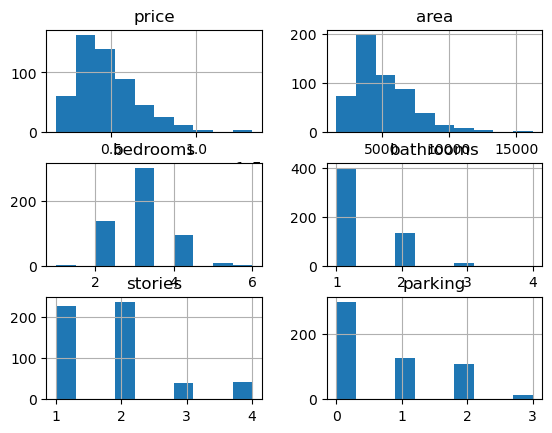

In [32]:
df.hist()

<Axes: ylabel='price'>

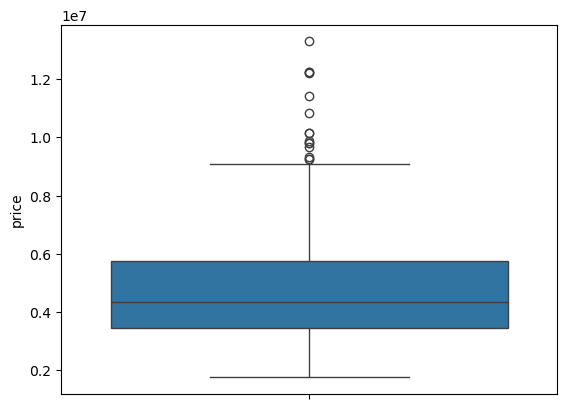

In [37]:
df.select_dtypes(include='number').columns.tolist()

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

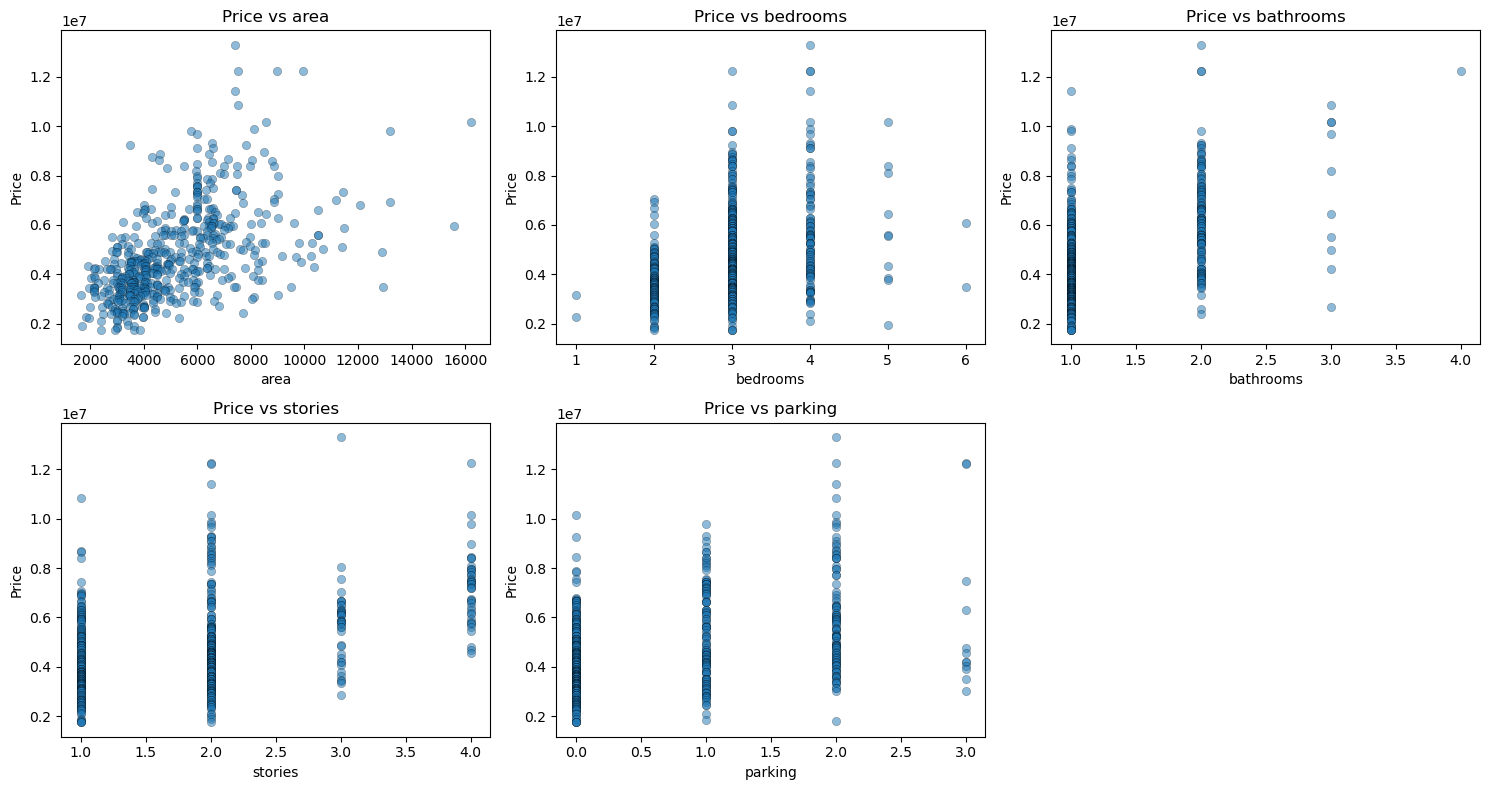

In [ ]:
import math
# Ambil semua kolom numerik kecuali 'price' itu sendiri
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'price']

# Atur layout grid
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df['price'], alpha=0.5, edgecolors='k', linewidths=0.3)
    axes[i].set_ylabel('Price')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Price vs {col}')

# Sembunyikan subplot kosong jika ada
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
ingin diuji: luas di atas rata memiliki harga rumah yang lebih mahal dibandingkan ruma

hr1 = harga rumah diatas luas rata rata
hr2 = harga rumah dibawah luas rata rata

h0: hr1 <= hr2
h1: hr1 > hr2